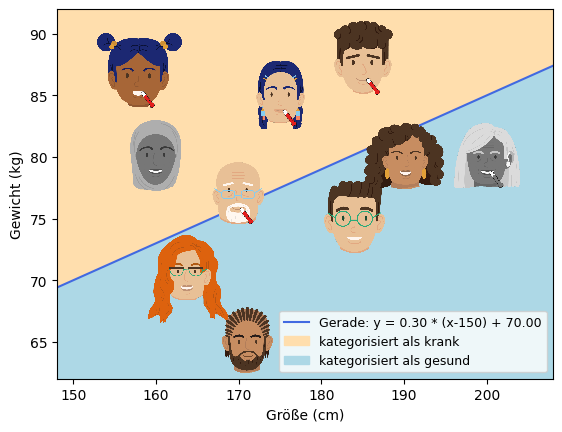

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import random

hoffset = 140
woffset = 50
cat_heights = [20, 24, 31, 44, 50]  # Größe zwischen 22 und 30 cm
cat_weights = [30, 20, 15, 25, 30]  # Gewicht zwischen 4 und 8 kg

cat_heights = [height+hoffset for height in cat_heights] 
cat_weights = [weight+woffset for weight in cat_weights] 


# Daten für Hunde
dog_heights = [18, 30, 35, 60, 45]  # Größe zwischen 45 und 65 cm
dog_weights = [37, 27, 35, 30, 38]  # Gewicht zwischen 15 und 35 kg

dog_heights = [height+hoffset for height in dog_heights] 
dog_weights = [weight+woffset for weight in dog_weights] 

# Lade Bilder EINMAL als Arrays (schnell und wiederverwendbar)
cat_img_arr=[]
cat_img_grey_arr=[]
dog_img_arr=[]
dog_img_grey_arr=[]

for i in range(len(cat_heights)):
    cat_img_arr.append(mpimg.imread('Grafiken/person'+str(i+1)+'a.png'))
    cat_img_grey_arr.append(mpimg.imread('Grafiken/person'+str(i+1)+'ab.png'))
    dog_img_arr.append(mpimg.imread('Grafiken/person'+str(i+6)+'a_krank.png'))
    dog_img_grey_arr.append(mpimg.imread('Grafiken/person'+str(i+6)+'ab_krank.png'))

def get_image_from_array(arr, zoom=0.07):
    return OffsetImage(arr, zoom=zoom)

def plot_with_distances(steigung=1.0, y_achsenabschnitt=0.0):
    fig, ax = plt.subplots()

    # Abstände berechnen und anzeigen
    total_distance_cats = 0
    total_distance_dogs = 0
    
    for i in range(len(cat_heights)):
        y_on_line = steigung * (cat_heights[i]-150) + y_achsenabschnitt
        if cat_weights[i]>y_on_line:
            image_data = cat_img_grey_arr[i]
            distance = cat_weights[i] - y_on_line
            total_distance_cats += distance
            # Linie für distanz zeichnen
            #ax.plot([cat_heights[i], cat_heights[i]], [y_on_line, cat_weights[i]], 'b-')
        else: 
            image_data = cat_img_arr[i]
        image = get_image_from_array(image_data)
        ab = AnnotationBbox(image, (cat_heights[i], cat_weights[i]), frameon=False)
        ax.add_artist(ab)
        #if image_data is cat_img_grey_arr:
        #    cat_count += 1

    
    for i in range(len(dog_heights)):
        y_on_line = steigung * (dog_heights[i]-150) + y_achsenabschnitt
        if dog_weights[i]<y_on_line:
            image_data = dog_img_grey_arr[i]
            distance = y_on_line - dog_weights[i]
            total_distance_dogs += distance
            # Linie für distanz zeichnen
            #ax.plot([dog_heights[i], dog_heights[i]], [dog_weights[i], y_on_line], 'g-')
        else:
            image_data = dog_img_arr[i]
        image = get_image_from_array(image_data)
        ab = AnnotationBbox(image, (dog_heights[i], dog_weights[i]), frameon=False)
        ax.add_artist(ab)


    # Gerade hinzufügen
    x_vals = np.linspace(148, 208, 100)  # Erzeuge 100 Werte zwischen 10 und 70
    y_vals = y_achsenabschnitt + steigung * (x_vals-150)  # Berechne die y-Werte basierend auf der Geradengleichung
    ax.plot(x_vals, y_vals, color='royalblue', label=f'Gerade: y = {steigung:.2f} * (x-150) + {y_achsenabschnitt:.2f}')

    # Bereich einfärben
    
    ax.fill_between(x_vals, y_vals, 92, where=(y_vals < 92), color='navajowhite', alpha=1, label='kategorisiert als krank')
    ax.fill_between(x_vals, y_vals, 62, color='lightblue', alpha=1, label='kategorisiert als gesund')

    # Achsenbeschriftungen und -limits setzen
    ax.set_xlim(148, 208)
    ax.set_ylim(62, 92)
    ax.set_xlabel('Größe (cm)')
    ax.set_ylabel('Gewicht (kg)')
    ax.legend(loc=4, prop={'size': 9})

    # Gesamtabstände ausgeben
    #print(f'Gewichtsdifferenzen der falsch kategorisierten gesunden Personen: {total_distance_cats:.2f}')
    #print(f'Gewichtsdifferenzen der falsch kategorisierten kranken Personen: {total_distance_dogs:.2f}')

    
    plt.show()

plot_with_distances(steigung=.3, y_achsenabschnitt=70)

In [3]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

#nltk.download('punkt')

In [4]:

file_path = 'Texte/kafka.txt'

with open(file_path, 'r') as file:
    text = file.read()

In [5]:
tokens = word_tokenize(text.lower())  # Tokenisierung und Kleinschreibung
window_size = 2  # Kontextfenster

# Training vorbereiten (als Liste von Sätzen)
sentences = [[token for token in tokens if token not in [',','.','-',':','!','?']]]


In [8]:
# Skip-Gram Modell trainieren
model = Word2Vec(sentences, vector_size=100, window=window_size, sg=1, min_count=1)

wort = "nur"
ähnliche_wörter = model.wv.most_similar(wort, topn=3)
print(f"Ähnliche Wörter zu '{wort}':")
for wort, wahrscheinlichkeit in ähnliche_wörter:
    print(f"{wort}: {wahrscheinlichkeit:.2f}")

Ähnliche Wörter zu 'nur':
körpers: 0.28
wie: 0.27
erwachte: 0.25


In [9]:
from collections import Counter

tokens = [token for token in tokens if token not in [',','.','-',':','!','?','(',')',';','–']]

def finde_kontexte_und_haeufigkeit(wort, tokens, fenster=2):
    kontext_woerter = []

    for i, token in enumerate(tokens):
        if token == wort:
            start = max(i - fenster, 0)
            end = min(i + fenster + 1, len(tokens))
            kontext = tokens[start:i] + tokens[i+1:end]
            kontext_woerter.extend(kontext)  # für Häufigkeit
            klen = len(kontext_woerter)
    # Häufigkeiten nach Vorkommen sortiert
    haeufigkeiten = Counter(kontext_woerter)
    haeufigkeiten = dict(sorted(haeufigkeiten.items(), key=lambda item: item[1], reverse=True))

    haeufigkeiten = {k: round(v / total,3) for total in (sum(haeufigkeiten.values()),) for k, v in haeufigkeiten.items()}
    
    return haeufigkeiten


wort="nur"
haeufigkeiten = finde_kontexte_und_haeufigkeit(wort, tokens, fenster=2)
haeufigkeiten

{'daß': 0.158,
 'wenn': 0.105,
 'nicht': 0.105,
 'dieses': 0.053,
 'wunder': 0.053,
 'eines': 0.053,
 'verletzt': 0.053,
 'zurück': 0.053,
 'ihm': 0.053,
 'er': 0.053,
 'konnte': 0.053,
 'essen': 0.053,
 'fühlte': 0.053,
 'und': 0.053,
 'bedauerte': 0.053}

In [10]:
import random
wort='bedauerte'
string=''
for i in range(100):
    haeufigkeiten = finde_kontexte_und_haeufigkeit(wort, tokens, fenster=1)
    häufigkeitenl = list(haeufigkeiten)

    while 1:
        neuesWort = häufigkeitenl[random.randint(0, len(häufigkeitenl)-1)]
        if wort != neuesWort:
            wort = neuesWort
            break
        
    
    #wort=häufigkeitenl[random.randint(0, len(häufigkeitenl)-1)]
    string+=' '+wort
string

' daß nur konnte hören konnte nur konnte entfernten konnte hören genau man jetzt erst spät erst bei erst jetzt schätzen lernte zur türe zur türe hin türe hin um ohne auch ohne nicht entfernt ein solches ein ihn er fest und trotzdem er wandte sich drängte sich setzte sich fühlte er sich wandte sich entfernten sich nicht mehr wie die sonst sein leben die über bis zum der geweckt der auf zimmer freie hohe das unter das gas angezündet gas angezündet aber sollte nehmen schrecken mit glücklich mit dem kopf er als zurückdrehte stück ein stilles ein stück zurückdrehte stück'

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, FileUpload
import torch
import torch.nn as nn
import torch.optim as optim

from fastbook import *
from fastai.vision.widgets import *
import os
import matplotlib.pyplot as plt
import platform
from PIL import Image, UnidentifiedImageError


import random
import math
import warnings

import time
from IPython.display import clear_output

import random
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from ipywidgets import interactive, widgets
from IPython.display import display, clear_output
import matplotlib.image as mpimg
import numpy as np


def hundOderKatzeAnhandGewicht_V2_zeichneVerlust():
    # Daten
    cat_heights = [20, 24, 31, 44, 50]
    cat_weights = [30, 20, 15, 25, 30]

    dog_heights = [18, 30, 35, 60, 45]
    dog_weights = [37, 27, 35, 30, 38]

    #Load images ONCE as arrays (fast and reusable)
    cat_img_arr = mpimg.imread('Grafiken/cathead.png')
    cat_img_grey_arr = mpimg.imread('Grafiken/cathead_grey.png')
    dog_img_arr = mpimg.imread('Grafiken/doghead.png')
    dog_img_grey_arr = mpimg.imread('Grafiken/doghead_grey.png')

    # Abstände berechnen und anzeigen
    total_distance_cats = 0
    total_distance_dogs = 0

    def calc_verlust(x):
        cat_heights = [20, 24, 31, 44, 50]
        cat_weights = [30, 20, 15, 25, 30]
    
        dog_heights = [18, 30, 35, 60, 45]
        dog_weights = [37, 27, 35, 30, 38]

        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            if cat_weights[i]> x:
                distance = cat_weights[i] - x
                total_distance_cats += distance
            
        for i in range(len(dog_heights)):
            if dog_weights[i]<x:
                distance = x - dog_weights[i]
                total_distance_dogs += distance
                
        return total_distance_cats+total_distance_dogs
    
    def get_image_from_array(arr, zoom=0.2):
        return OffsetImage(arr, zoom=zoom)

    def plot_counting(y_achsenabschnitt=0.0):
        clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        steigung=0
        # Abstände berechnen und anzeigen
        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            y_on_line = steigung * cat_heights[i] + y_achsenabschnitt
            if cat_weights[i]>y_on_line:
                image_data = cat_img_grey_arr
                distance = cat_weights[i] - y_on_line
                total_distance_cats += distance
                # Linie für distanz zeichnen
                ax[0].plot([cat_heights[i], cat_heights[i]], [y_on_line, cat_weights[i]], 'b-')
            else: 
                image_data = cat_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (cat_heights[i], cat_weights[i]), frameon=False)
            ax[0].add_artist(ab)
            
        for i in range(len(dog_heights)):
            y_on_line = steigung*dog_heights[i]+y_achsenabschnitt
            if dog_weights[i]<y_on_line:
                image_data = dog_img_grey_arr 
                distance = y_on_line - dog_weights[i]
                total_distance_dogs += distance
                # Linie für distanz zeichnen
                ax[0].plot([dog_heights[i], dog_heights[i]], [dog_weights[i], y_on_line], 'g-')
            else:
                image_data = dog_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (dog_heights[i], dog_weights[i]), frameon=False)
            ax[0].add_artist(ab)

        # Draw decision boundary
        x_vals = np.linspace(10, 70, 100)
        y_vals = y_achsenabschnitt + 0 * x_vals
        ax[0].plot(x_vals, y_vals, color='royalblue', label=f'Grenze bei {y_achsenabschnitt:.2f} kg')

        # Bereich einfärben
        ax[0].fill_between(x_vals, y_vals, 12, color='lightblue', alpha=1, label='kategorisiert als Katze')
        ax[0].fill_between(x_vals, y_vals, 42, where=(y_vals < 42), color='navajowhite', alpha=1, label='kategorisiert als Hund')

        ax[0].set_xlim(10, 68)
        ax[0].set_ylim(12, 42)
        ax[0].set_xlabel('Größe (cm)')
        ax[0].set_ylabel('Gewicht (kg)')
        ax[0].legend()

        # Vectorize the function to handle arrays
        vectorized_verlust = np.vectorize(calc_verlust)
        
        x2_vals = np.linspace(10,50,100)
        y2_vals = vectorized_verlust(x2_vals)

        ax[1].set_xlabel('Gewichtsgrenze (kg)')
        ax[1].set_ylabel('Verlust')
        ax[1].plot(x2_vals, y2_vals, color="royalblue")
        ax[1].plot(y_achsenabschnitt, calc_verlust(y_achsenabschnitt), 'ro') 

        plt.show()

    randomY = random.uniform(10, 50)
    w = interactive(plot_counting, y_achsenabschnitt=widgets.FloatSlider(min=10, max=50, step=0.05, value=randomY))
    display(w)

hundOderKatzeAnhandGewicht()

interactive(children=(FloatSlider(value=18.92842952595291, description='y_achsenabschnitt', max=50.0, min=10.0…

In [3]:
def hundOderKatzeAnhandGewicht_V1_zeichneVerlust():
    # Daten
    cat_heights = [20, 24, 31, 44, 50]
    cat_weights = [30, 20, 15, 25, 30]

    dog_heights = [18, 30, 35, 60, 45]
    dog_weights = [37, 27, 35, 30, 38]

    #Load images ONCE as arrays (fast and reusable)
    cat_img_arr = mpimg.imread('Grafiken/cathead.png')
    cat_img_grey_arr = mpimg.imread('Grafiken/cathead_grey.png')
    dog_img_arr = mpimg.imread('Grafiken/doghead.png')
    dog_img_grey_arr = mpimg.imread('Grafiken/doghead_grey.png')

    # Abstände berechnen und anzeigen
    total_distance_cats = 0
    total_distance_dogs = 0

    def calc_verlust(x):
        cat_heights = [20, 24, 31, 44, 50]
        cat_weights = [30, 20, 15, 25, 30]
    
        dog_heights = [18, 30, 35, 60, 45]
        dog_weights = [37, 27, 35, 30, 38]

        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            if cat_weights[i]> x:
                total_distance_cats += 1
            
        for i in range(len(dog_heights)):
            if dog_weights[i]<x:
                total_distance_dogs += 1
                
        return total_distance_cats+total_distance_dogs
    
    def get_image_from_array(arr, zoom=0.2):
        return OffsetImage(arr, zoom=zoom)

    def plot_counting(y_achsenabschnitt=0.0):
        clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        steigung=0
        # Abstände berechnen und anzeigen
        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            y_on_line = steigung * cat_heights[i] + y_achsenabschnitt
            if cat_weights[i]>y_on_line:
                image_data = cat_img_grey_arr
                total_distance_cats += 1
                # Linie für distanz zeichnen
                ax[0].plot([cat_heights[i], cat_heights[i]], [y_on_line, cat_weights[i]], 'b-')
            else: 
                image_data = cat_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (cat_heights[i], cat_weights[i]), frameon=False)
            ax[0].add_artist(ab)
            
        for i in range(len(dog_heights)):
            y_on_line = steigung*dog_heights[i]+y_achsenabschnitt
            if dog_weights[i]<y_on_line:
                image_data = dog_img_grey_arr 
                total_distance_dogs += 1
                # Linie für distanz zeichnen
                ax[0].plot([dog_heights[i], dog_heights[i]], [dog_weights[i], y_on_line], 'g-')
            else:
                image_data = dog_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (dog_heights[i], dog_weights[i]), frameon=False)
            ax[0].add_artist(ab)

        # Draw decision boundary
        x_vals = np.linspace(10, 70, 100)
        y_vals = y_achsenabschnitt + 0 * x_vals
        ax[0].plot(x_vals, y_vals, color='royalblue', label=f'Grenze bei {y_achsenabschnitt:.2f} kg')

        # Bereich einfärben
        ax[0].fill_between(x_vals, y_vals, 12, color='lightblue', alpha=1, label='kategorisiert als Katze')
        ax[0].fill_between(x_vals, y_vals, 42, where=(y_vals < 42), color='navajowhite', alpha=1, label='kategorisiert als Hund')

        ax[0].set_xlim(10, 68)
        ax[0].set_ylim(12, 42)
        ax[0].set_xlabel('Größe (cm)')
        ax[0].set_ylabel('Gewicht (kg)')
        ax[0].legend()

        # Vectorize the function to handle arrays
        vectorized_verlust = np.vectorize(calc_verlust)
        
        x2_vals = np.linspace(10,50,100)
        y2_vals = vectorized_verlust(x2_vals)

        ax[1].set_xlabel('Gewichtsgrenze (kg)')
        ax[1].set_ylabel('Verlust')
        ax[1].plot(x2_vals, y2_vals, color="royalblue")
        ax[1].plot(y_achsenabschnitt, calc_verlust(y_achsenabschnitt), 'ro') 

        plt.show()

    randomY = random.uniform(10, 50)
    w = interactive(plot_counting, y_achsenabschnitt=widgets.FloatSlider(min=10, max=50, step=0.05, value=randomY))
    display(w)

hundOderKatzeAnhandGewicht_V1_zeichneVerlust()

interactive(children=(FloatSlider(value=21.001172734764772, description='y_achsenabschnitt', max=50.0, min=10.…

In [21]:

def hundOderKatzeMitGerade():

    # Feste Werte für Größe (in cm) und Gewicht (in kg)
    # Daten für Katzen
    cat_heights = [20, 24, 31, 44, 50]  # Größe zwischen 22 und 30 cm
    cat_weights = [30, 20, 15, 25, 30]  # Gewicht zwischen 4 und 8 kg

    # Daten für Hunde
    dog_heights = [18, 30, 35, 60, 45]  # Größe zwischen 45 und 65 cm
    dog_weights = [37, 27, 35, 30, 38]  # Gewicht zwischen 15 und 35 kg

    # Lade Bilder EINMAL als Arrays (schnell und wiederverwendbar)
    cat_img_arr = mpimg.imread('Grafiken/cathead.png')
    cat_img_grey_arr = mpimg.imread('Grafiken/cathead_grey.png')
    dog_img_arr = mpimg.imread('Grafiken/doghead.png')
    dog_img_grey_arr = mpimg.imread('Grafiken/doghead_grey.png')


    #change calc_verlust ------------------------- implement 2ax fig plot
    def calc_verlust(steigung, y_achsenabschnitt):
        cat_heights = [20, 24, 31, 44, 50]
        cat_weights = [30, 20, 15, 25, 30]
    
        dog_heights = [18, 30, 35, 60, 45]
        dog_weights = [37, 27, 35, 30, 38]

        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            y_on_line = steigung * cat_heights[i] + y_achsenabschnitt
            if cat_weights[i]> y_on_line:
                distance = cat_weights[i] - y_on_line
                total_distance_cats += distance
            
        for i in range(len(dog_heights)):
            y_on_line = steigung*dog_heights[i]+y_achsenabschnitt
            if dog_weights[i]<y_on_line:
                distance = y_on_line - dog_weights[i]
                total_distance_dogs += distance
                
        return total_distance_cats+total_distance_dogs

    def get_image_from_array(arr, zoom=0.2):
        return OffsetImage(arr, zoom=zoom)

    def plot_with_distances(steigung=1.0, y_achsenabschnitt=0.0):
        clear_output(wait=True)
        
        fig = plt.figure(figsize=(10, 5))

        # 2D subplot on the left
        ax1 = fig.add_subplot(1, 2, 1)
        
        # 3D subplot on the right
        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        
        
        # Abstände berechnen und anzeigen
        total_distance_cats = 0
        total_distance_dogs = 0
        
        for i in range(len(cat_heights)):
            y_on_line = steigung * cat_heights[i] + y_achsenabschnitt
            if cat_weights[i]>y_on_line:
                image_data = cat_img_grey_arr
                distance = cat_weights[i] - y_on_line
                total_distance_cats += distance
                # Linie für distanz zeichnen
                ax1.plot([cat_heights[i], cat_heights[i]], [y_on_line, cat_weights[i]], 'b-')
            else: 
                image_data = cat_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (cat_heights[i], cat_weights[i]), frameon=False)
            ax1.add_artist(ab)
            #if image_data is cat_img_grey_arr:
            #    cat_count += 1

        
        for i in range(len(dog_heights)):
            y_on_line = steigung*dog_heights[i]+y_achsenabschnitt
            if dog_weights[i]<y_on_line:
                image_data = dog_img_grey_arr 
                distance = y_on_line - dog_weights[i]
                total_distance_dogs += distance
                # Linie für distanz zeichnen
                ax1.plot([dog_heights[i], dog_heights[i]], [dog_weights[i], y_on_line], 'g-')
            else:
                image_data = dog_img_arr
            image = get_image_from_array(image_data)
            ab = AnnotationBbox(image, (dog_heights[i], dog_weights[i]), frameon=False)
            ax1.add_artist(ab)
            #if image_data is dog_img_grey_arr:
            #    dog_count += 1

        # Draw decision boundary
        x_vals = np.linspace(10, 70, 100)
        y_vals = y_achsenabschnitt + steigung * x_vals
        ax1.plot(x_vals, y_vals, color='royalblue', label=f'Gerade: y = {steigung:.2f}x + {y_achsenabschnitt:.2f}')

        # Bereich einfärben
        
        ax1.fill_between(x_vals, y_vals, 42, where=(y_vals < 42), color='navajowhite', alpha=1, label='kategorisiert als Hund')
        ax1.fill_between(x_vals, y_vals, 12, color='lightblue', alpha=1, label='kategorisiert als Katze')

        ax1.set_xlim(10, 68)
        ax1.set_ylim(12, 42)
        ax1.set_xlabel('Größe (cm)')
        ax1.set_ylabel('Gewicht (kg)')
        ax1.legend()


        # Vectorize the function to handle arrays
        vectorized_verlust = np.vectorize(calc_verlust)

        x2_vals = np.linspace(-1,1,100)
        y2_vals = np.linspace(10,50,100)
    
        x2_vals, y2_vals = np.meshgrid(x2_vals, y2_vals)
        z2_vals = vectorized_verlust(x2_vals,y2_vals)


        
        
        #ax[1].set_xlabel('Gewicht (kg)')
        #ax[1].set_ylabel('Verlust')
        #ax2.plot_surface(x2_vals, y2_vals, z2_vals)
        ax2.plot_surface(x2_vals, y2_vals, z2_vals, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,alpha=0.3,zorder=1)
        #ax2.plot_wireframe(x2_vals, y2_vals, z2_vals, rstride=10, cstride=10, zorder=1)
        ax2.plot(steigung, y_achsenabschnitt, calc_verlust(steigung,y_achsenabschnitt), "ro", zorder=10)
        #ax[1].plot(y_achsenabschnitt, calc_verlust(y_achsenabschnitt), 'ro') 
        

        plt.show()

    randomSteigung = random.uniform(-1,1)
    randomY = random.uniform(10,50)
    # Interaktiver Plot mit anpassbarer Gerade und Möglichkeit, den Plot zu speichern 
    interact(plot_with_distances, 
            steigung=widgets.FloatSlider(min=-1, max=1, step=0.05, value=randomSteigung),
            y_achsenabschnitt=widgets.FloatSlider(min=10, max=50, step=0.05, value=randomY))

hundOderKatzeMitGerade()

interactive(children=(FloatSlider(value=0.2370395047284921, description='steigung', max=1.0, min=-1.0, step=0.…